In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [166]:
df = pd.read_csv("Social_Network_Ads.csv")
df.shape

(400, 5)

In [167]:
df=df.iloc[:,2:]
df.shape

(400, 3)

In [168]:
df.sample(5)

,Age,EstimatedSalary,Purchased
293,37,77000,0
398,36,33000,0
94,29,83000,0
124,41,51000,0
297,43,112000,1


## Train test Split 

In [169]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(df.drop(('Purchased'),axis=1),df['Purchased'],test_size=0.3,random_state=50)

# in train test split the elements are passed in following way 
# train_test_split(input (x) , output (y) ,test_size=0.3,random_state=0.34)

X_train.shape ,X_test.shape, y_train.shape , y_test.shape

((280, 2), (120, 2), (280,), (120,))

## Standard Scaler

In [170]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler() # standard scaler class do the samething that we have discussed in our notes ( use the same formula )

scalar.fit(X_train) # Fit the scaler to the train set , it will learn the parameters like mean and standard deviation 

# Transform train test splits 
X_train_scale = scalar.transform(X_train)
X_test_scale = scalar.transform(X_test)

In [171]:
scalar.mean_ # this is the mean of the column age and salary present in the X_train datasets 

array([3.82321429e+01, 6.93464286e+04])

In [172]:
X_train

,Age,EstimatedSalary
114,42,80000
25,47,20000
99,28,37000
90,22,81000
271,59,76000
...,...,...
132,30,87000
289,37,78000
109,38,80000
395,46,41000


In [173]:
X_train_scale # this is not in pandas dataframe format , it is in numpy format so we need to convert it into pandas dataframe

array([[ 0.35127862,  0.31209255],
       [ 0.81743034, -1.44558592],
       [-0.95394621, -0.94757702],
       [-1.51332828,  0.34138719],
       [ 1.93619448,  0.19491399],
       [-0.1148731 ,  0.16561935],
       [ 1.84296414,  2.18694959],
       [ 1.19035172, -1.357702  ],
       [-0.39456414, -0.77180917],
       [-0.02164276,  1.27881571],
       [-0.76748552,  1.92329782],
       [-0.48779448, -0.27380027],
       [-0.67425517,  1.42528892],
       [ 0.16481793, -0.24450563],
       [-0.86071586,  0.31209255],
       [-1.1404069 ,  0.4878604 ],
       [ 0.44450897,  1.86470854],
       [-0.1148731 ,  0.22420863],
       [ 1.28358207,  1.30811036],
       [-0.02164276, -0.24450563],
       [ 0.25804828,  0.51715504],
       [-0.76748552,  1.10304787],
       [ 1.09712138,  0.54644968],
       [-1.32686759, -1.47488056],
       [ 0.7242    , -1.09405023],
       [-1.23363724, -1.38699664],
       [-1.04717655, -1.12334487],
       [ 0.07158759,  0.16561935],
       [-0.58102483,

In [174]:
y_train

114    0
25     1
99     0
90     0
271    1
      ..
132    0
289    1
109    0
395    1
176    0
Name: Purchased, Length: 280, dtype: int64

In [175]:
X_train_scale = pd.DataFrame(X_train_scale,columns=X_train.columns) # this convert it into pandas dataframe 
X_test_scale = pd.DataFrame(X_test_scale,columns=X_test.columns)

In [176]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,38.2,69346.4
std,10.7,34197.1
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,69500.0
75%,47.0,88000.0
max,60.0,150000.0


In [177]:
X_train_scale

,Age,EstimatedSalary
0,0.351279,0.312093
1,0.817430,-1.445586
2,-0.953946,-0.947577
3,-1.513328,0.341387
4,1.936194,0.194914
...,...,...
275,-0.767486,0.517155
276,-0.114873,0.253503
277,-0.021643,0.312093
278,0.724200,-0.830398


## Effect of scaling 

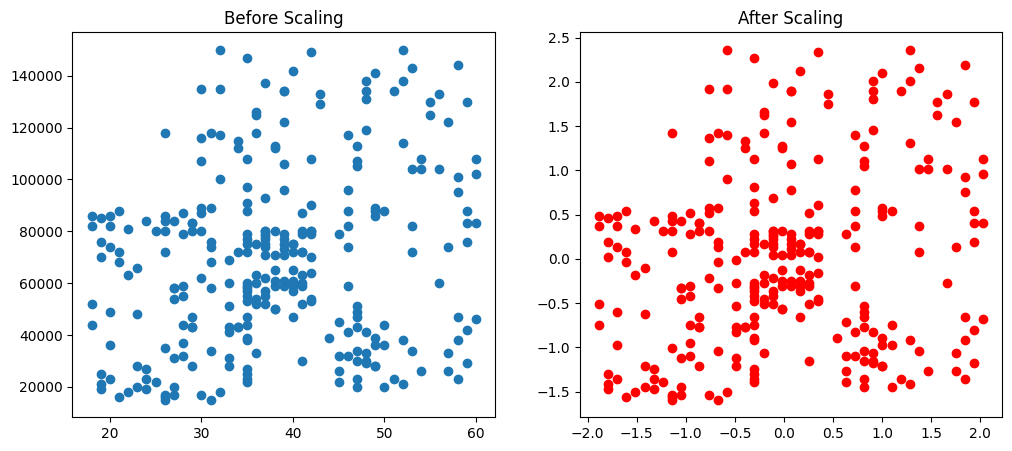

In [178]:
fig , (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
# Subplot create an empty space where we can draw any graph we want , we can set ncols of how much graph we want 

ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scale['Age'],X_train_scale['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

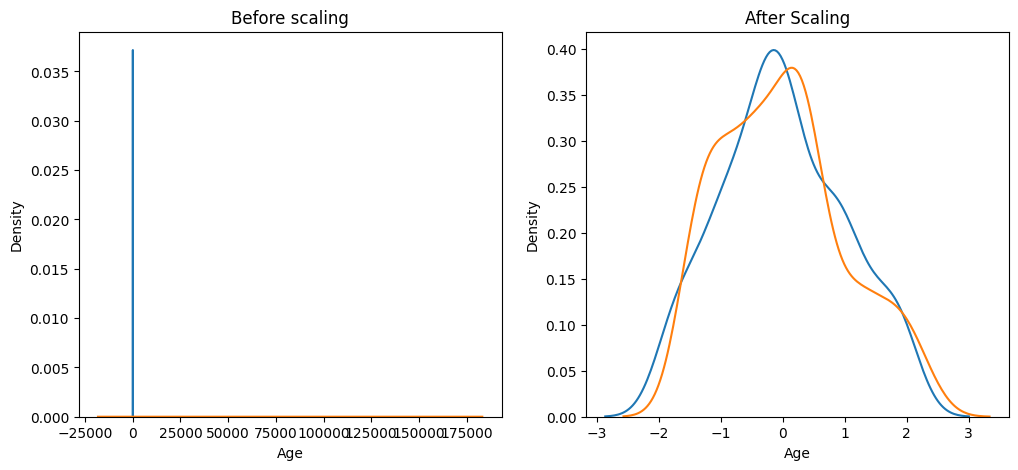

In [179]:
# A KDE plot is a smooth curve that estimates the probability density (distribution) of a continuous numerical variable.
# KDE stands for Kernel Density Estimation.
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5)) # here gigsize=(width,height)

#before scaling 
ax1.set_title("Before scaling")
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

# after scaling 
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scale['Age'],ax=ax2)
sns.kdeplot(X_train_scale['EstimatedSalary'],ax=ax2)
plt.show()

## Comparison of distribution 

In [180]:
# The distribution remain same after and before scaling 

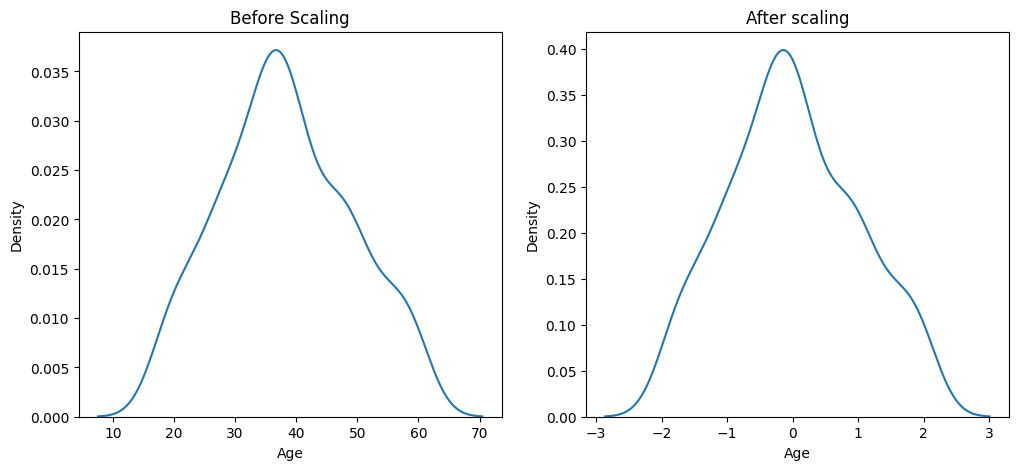

In [181]:
fig , (ax1,ax2) = plt.subplots(ncols = 2,figsize=(12,5))

# before scaling 
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Age'],ax=ax1)

# afetr scaling 
ax2.set_title("After scaling")
sns.kdeplot(X_train_scale['Age'],ax=ax2)
plt.show()

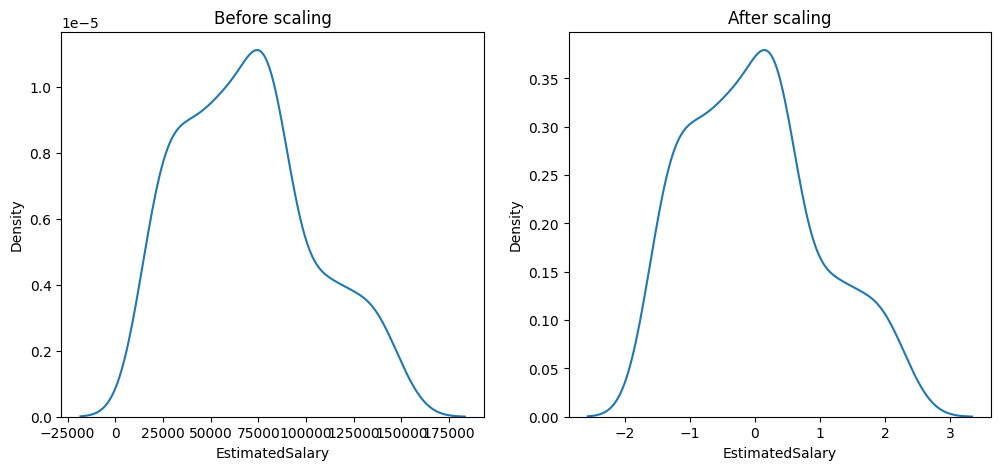

In [182]:
fig , (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title("Before scaling")
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

ax2.set_title("After scaling")
sns.kdeplot(X_train_scale['EstimatedSalary'],ax=ax2)

plt.show()

## Why scaling is important 

In [183]:
from sklearn.linear_model import LogisticRegression 

In [184]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [185]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scale,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [186]:
y_predict = lr.predict(X_test)
y_predict_scale = lr_scaled.predict(X_test_scale)

In [187]:
from sklearn.metrics import accuracy_score


In [ ]:
print("Actual : ",accuracy_score(y_test,y_predict))
print("Scaled : ",accuracy_score(y_test,y_predict_scale))

# It is not neccesary that the model which is scaled gives high accuracy 

Actual :  0.8583333333333333
Scaled :  0.8583333333333333


In [ ]:
# Now i am using the model which do not depend upon the scaling 

In [189]:
from sklearn.tree import DecisionTreeClassifier

In [190]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()


In [193]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scale,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [195]:
y_predict = dt.predict(X_test)
y_predict_scaled = dt_scaled.predict(X_test_scale)

In [196]:
actual = accuracy_score(y_test,y_predict)
scaled = accuracy_score(y_test,y_predict_scaled)

In [197]:
actual,scaled

(0.85, 0.85)

In [198]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


## Effect of outlier 

In [ ]:
new_rows = pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]},ignore_index=True)

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (463962441.py, line 1)